# **Iris Flower Classification**

Training a computer to recognize 3 types of iris flowers *(Setosa, Versicolor, Virginica)* just by looking at their measurements *(sepal length, sepal width, petal length, petal width)* .

**1: Importing the Required Libraries.**

In [1]:
import pandas as pd                        # for reading csv files
import numpy as np                         # for numerical operations (array)
import matplotlib.pyplot as plt            # for graph
import seaborn as sns                      # for advance graphs
from sklearn.model_selection import train_test_split   # for spliting data into train and test set
from sklearn.preprocessing import LabelEncoder # for converting the text into numbers
from sklearn.ensemble import RandomForestClassifier # our ML model
from sklearn.metrics import accuracy_score, classification_report # for checking out model's accuracy and result


**2: Load the dataset**

In [2]:
df = pd.read_csv('Iris.csv')


**3: EDA (Exploratory Data Analysis)**

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

In [5]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [6]:
print('How many Species are there? ')
print(df['Species'].value_counts())

How many Species are there? 
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [7]:
df = df.drop('Id', axis=1)

In [8]:
print('Basic Statistics')
round(df.describe(), 2)

Basic Statistics


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


From these operations we can say that the dataset given is already clean.

**4: Data Visualisations**

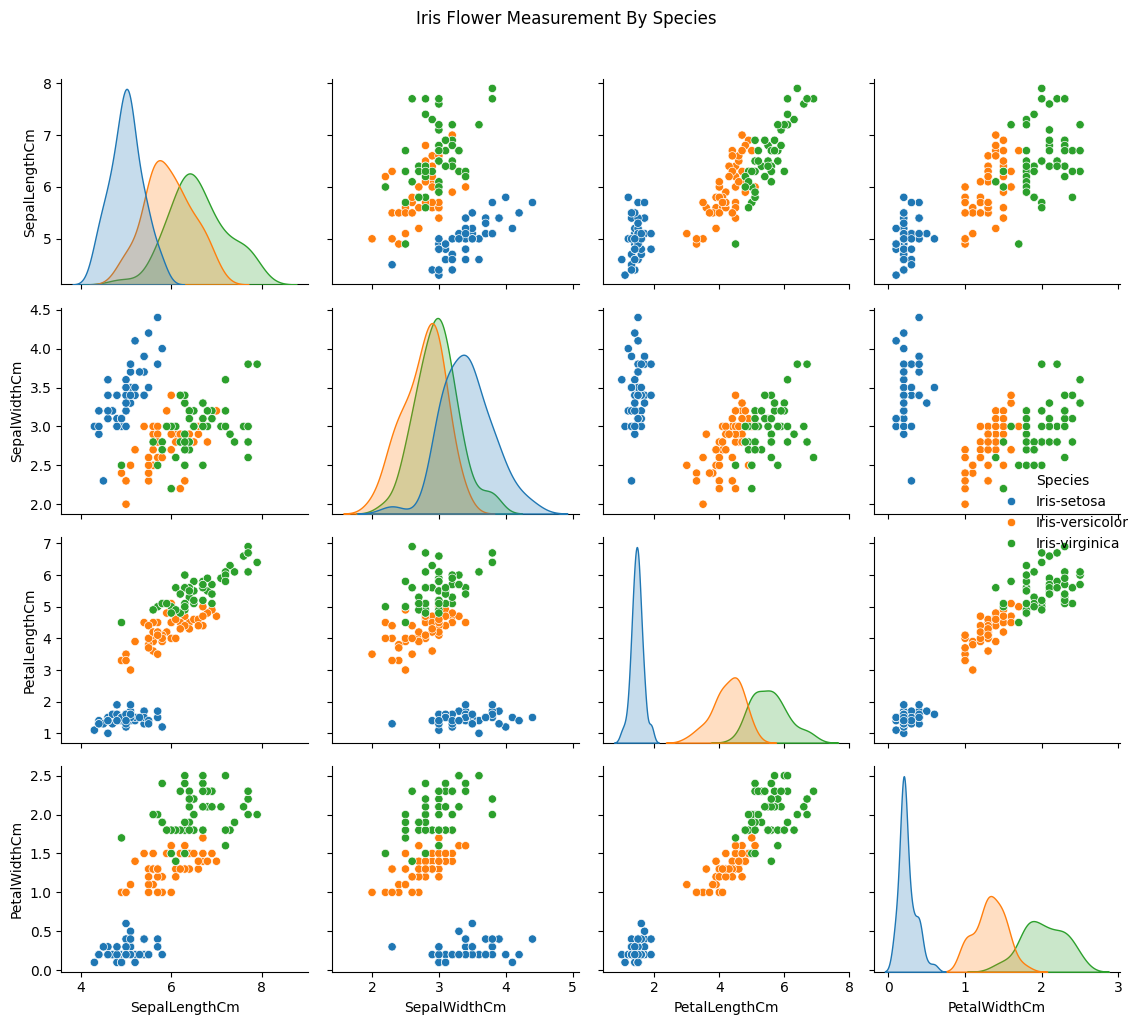

In [9]:
sns.pairplot(df, hue='Species')
plt.suptitle('Iris Flower Measurement By Species', y=1.02)
plt.tight_layout()
plt.savefig('pairplot.png')   # used for saving graph as image
plt.show()


Here, I have used ***Pairplot Matrix*** to check the relationship between all the numerical features at once.

**5: Preparing the data for training**

ML models only understand NUMBERS, not text like "Iris-setosa", So we convert species names to numbers: 0, 1, 2

For that we will use Label Encoding as we have only 3 species.

In [10]:
# selecting the input(x) and output(y) variables
x = df.drop(['Species'], axis=1)   # input = measurements
y = df['Species']                  # output = species

Encoding the text(species) into numbers.

In [11]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Species Mapping

In [12]:
print('Species Mapping')
for i, name in enumerate(le.classes_):
    print(f"  {i} : {name}")

Species Mapping
  0 : Iris-setosa
  1 : Iris-versicolor
  2 : Iris-virginica


**6: Spliting the Dataset into Train Set and Test Set**

Here, we will use 80% of dataset as Train Dataset and remaining 20% as Test Dataset.

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y_encoded,
    test_size = 0.2,    # 20% as test set
    random_state = 42   # it will make sure that split is same everytime you run the program
)

print(f'Total Samples:    {len(df)}')
print(f'Training Samples: {len(x_train)}')
print(f'Testing Samples:  {len(x_test)}')

Total Samples:    150
Training Samples: 120
Testing Samples:  30


**7: Training the ML Model**

I have use Random Forest as it's like asking many decision trees and taking a majority vote.

In [14]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

print('Model Training Completed')

Model Training Completed


**8: Testing the Model**

Evaluating the classification model using accuracy, precision, recall, and F1-score

In [15]:
y_pred = model.predict(x_test)   # model's guesses on test dataset

accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy * 100} %')
print()
print(classification_report(y_test, y_pred))

Model Accuracy: 100.0 %

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**9: Predict on a New Flower**


Let's say someone gives us measurements of an unknown flower, Our model will guess what species it is

In [18]:
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]],
                          columns=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"])

prediction = model.predict(new_flower)
predicted_species = le.inverse_transform(prediction)

print(f'Predicted Species: {predicted_species[0]}')

Predicted Species: Iris-setosa


In [20]:
import joblib
joblib.dump((model, le) ,"iris_model.pkl")

['iris_model.pkl']